<a href="https://colab.research.google.com/github/BONNIEVITTOALZAIN/AI-Capstone-DC/blob/master/notebooks/receipt_text_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!python -m pip install paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/
!python -m pip install "paddleocr[all]"
!pip install -U google-genai

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/


In [2]:
import sys
import os
from dotenv import load_dotenv
from google.colab import files
from google import genai
import json

if 'paddleocr' not in sys.modules:
    from paddleocr import PaddleOCR

In [3]:
ocr = PaddleOCR(
  use_angle_cls=True,
  enable_mkldnn=False,
  lang='en',
  ocr_version='PP-OCRv4'
)

/tmp/ipykernel_8768/1587976003.py:1: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already ex

In [4]:
file_name = ''
uploaded = files.upload()
for key in uploaded.keys():
  file_name = key

Saving CONTOH STRUK PEMBAYARAN INDOMARET.webp to CONTOH STRUK PEMBAYARAN INDOMARET.webp


In [5]:
result = ocr.predict(f'./{file_name}')

In [6]:
texts = []

for res in result:
    texts = res['rec_texts']

In [7]:
env_upload = files.upload()

Saving .env to .env


In [8]:
load_dotenv('/content/.env')

True

In [9]:
API_KEY = os.getenv("API_KEY")
client = genai.Client(api_key=API_KEY)

response = client.models.generate_content(
    model='gemini-flash-latest',
    contents=f'''
      {texts}
      Extract only the item name (without item code), quantity, and price from the data above and make it into a structured json data.
      Example: "items" : ["item_name": ..., "quantity": ..., "price": ...]
      If there are discounts, directly apply it to the price. Don't need to write the discount information.
      If the item name is not separated properly, separate it with whitespace.
    '''
)

print(response.text)

```json
{
  "items": [
    {
      "item_name": "JAVANA TEH MLATI 350",
      "quantity": 5,
      "price": 13800
    }
  ]
}
```


In [10]:
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/antigravity-preview-05-2026
models/

In [11]:
def inference(file_name):
  predicted = ocr.predict(f'./{file_name}')

  texts = []
  for res in predicted:
    texts = res['rec_texts']

  response = client.models.generate_content(
    model='gemini-flash-latest',
    contents=f'''
      {texts}
      Extract only the item name (without item code), quantity, and price from the data above and make it into a structured json data.
      Example: ["item_name": ..., "quantity": ..., "price": ...]
      If there are discounts, directly apply it to the price. Don't need to write the discount information.
      If the item name is not separated properly, separate it with whitespace.
    '''
  )

  result = response.text
  result = result.replace('```json', '').replace('```', '').strip()
  result = json.loads(result)

  return result

In [12]:
file_name = ''
uploaded = files.upload()
for key in uploaded.keys():
  file_name = key

result = inference(file_name)
print(result)

Saving CONTOH STRUK PEMBAYARAN INDOMARET.webp to CONTOH STRUK PEMBAYARAN INDOMARET (1).webp
[{'item_name': 'JAVANA TEH MLATI 350', 'quantity': 5, 'price': 13800}]


**Contoh Gambar untuk Inference**

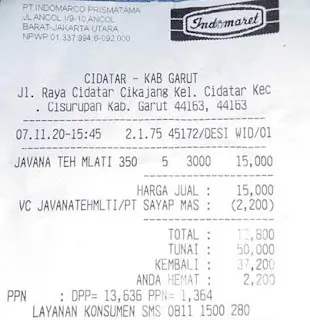